# Notebook 01 — Beer-Lambert Absorption Law

## Overview
This notebook demonstrates the **Beer-Lambert law**, the foundation of atmospheric absorption modelling.

When solar photons travel through a gas, each photon has a probability of being absorbed by a molecule. The cumulative effect over a path of length $L$ is:

$$I(\nu) = I_0(\nu) \cdot e^{-\tau(\nu)}$$

where the **optical depth** $\tau(\nu) = \sigma(\nu) \cdot n \cdot L$ characterises the total absorption.

| Symbol | Meaning | Units |
|--------|---------|-------|
| $I_0(\nu)$ | Incident radiance | W m⁻² sr⁻¹ cm |
| $\sigma(\nu)$ | Absorption cross section | cm²/molecule |
| $n$ | Molecular number density | molecules/cm³ |
| $L$ | Path length | cm |

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from absorption import (
    optical_depth,
    transmittance,
    radiance,
    number_density_from_pT,
    multilayer_optical_depth,
    demo_beer_lambert,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Molecular Number Density from Ideal Gas Law

$$n = \frac{P \cdot x_{CO_2}}{k_B \cdot T}$$

In [2]:
# Representative mid-troposphere conditions
P   = 50000.0   # Pa  (≈ 500 hPa)
T   = 255.0     # K
vmr = 420e-6    # 420 ppm CO₂

n_co2 = number_density_from_pT(P, T, vmr)
print(f'CO₂ number density: {n_co2:.3e} molecules/cm³')

# Compare to pure air at the same P and T
n_air = number_density_from_pT(P, T, mole_fraction=1.0)
print(f'Air number density:  {n_air:.3e} molecules/cm³')
print(f'CO₂ fraction:        {n_co2/n_air * 1e6:.1f} ppm  ✓')

CO₂ number density: 5.965e+15 molecules/cm³
Air number density:  1.420e+19 molecules/cm³
CO₂ fraction:        420.0 ppm  ✓


## 2. Single-Wavelength Beer-Lambert Demonstration

Fix $\nu = 6250$ cm⁻¹ (1.6 µm CO₂ band) and vary path length.

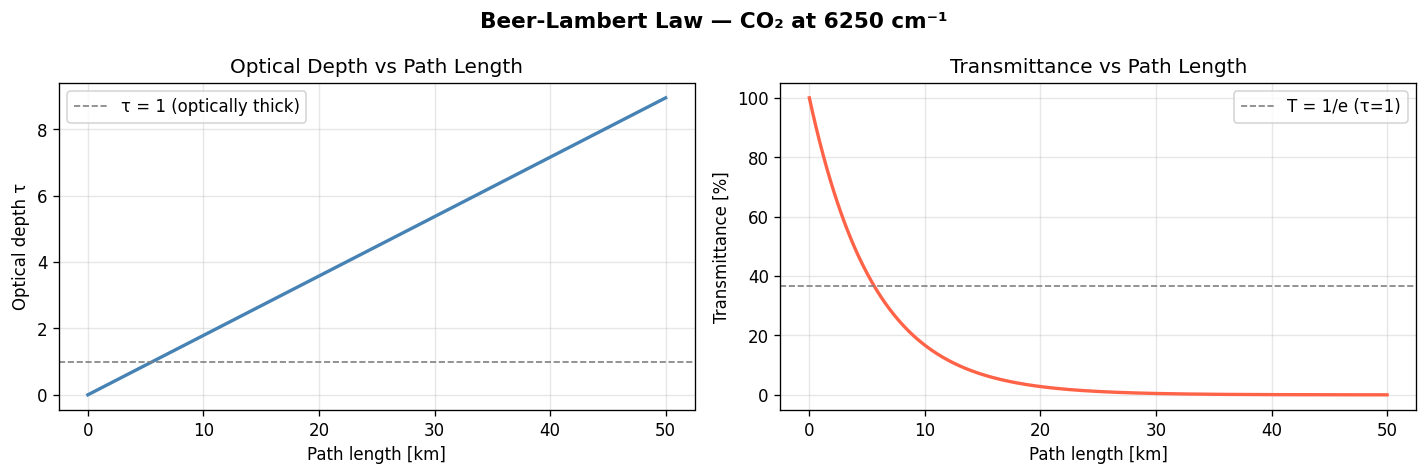

In [5]:
# Typical CO₂ cross section at 6250 cm⁻¹ (simplified Gaussian approximation)
sigma_peak = 3e-22  # cm²/molecule

# Path lengths from 1 km to 50 km (converted to cm)
L_km = np.linspace(0, 50, 500)
L_cm = L_km * 1e5  # 1 km = 1e5 cm

tau_values  = optical_depth(sigma_peak, n_co2, L_cm)
trans_values = transmittance(tau_values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(L_km, tau_values, color='steelblue', lw=2)
ax1.axhline(1, color='gray', ls='--', lw=1, label='τ = 1 (optically thick)')
ax1.set_xlabel('Path length [km]')
ax1.set_ylabel('Optical depth τ')
ax1.set_title('Optical Depth vs Path Length')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(L_km, trans_values * 100, color='tomato', lw=2)
ax2.axhline(36.8, color='gray', ls='--', lw=1, label='T = 1/e (τ=1)')
ax2.set_xlabel('Path length [km]')
ax2.set_ylabel('Transmittance [%]')
ax2.set_title('Transmittance vs Path Length')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Beer-Lambert Law — CO₂ at 6250 cm⁻¹', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/01a_beer_lambert_single_wavelength.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Spectral Beer-Lambert Absorption

Now we apply the Beer-Lambert law across the full spectral grid with a Gaussian cross section.

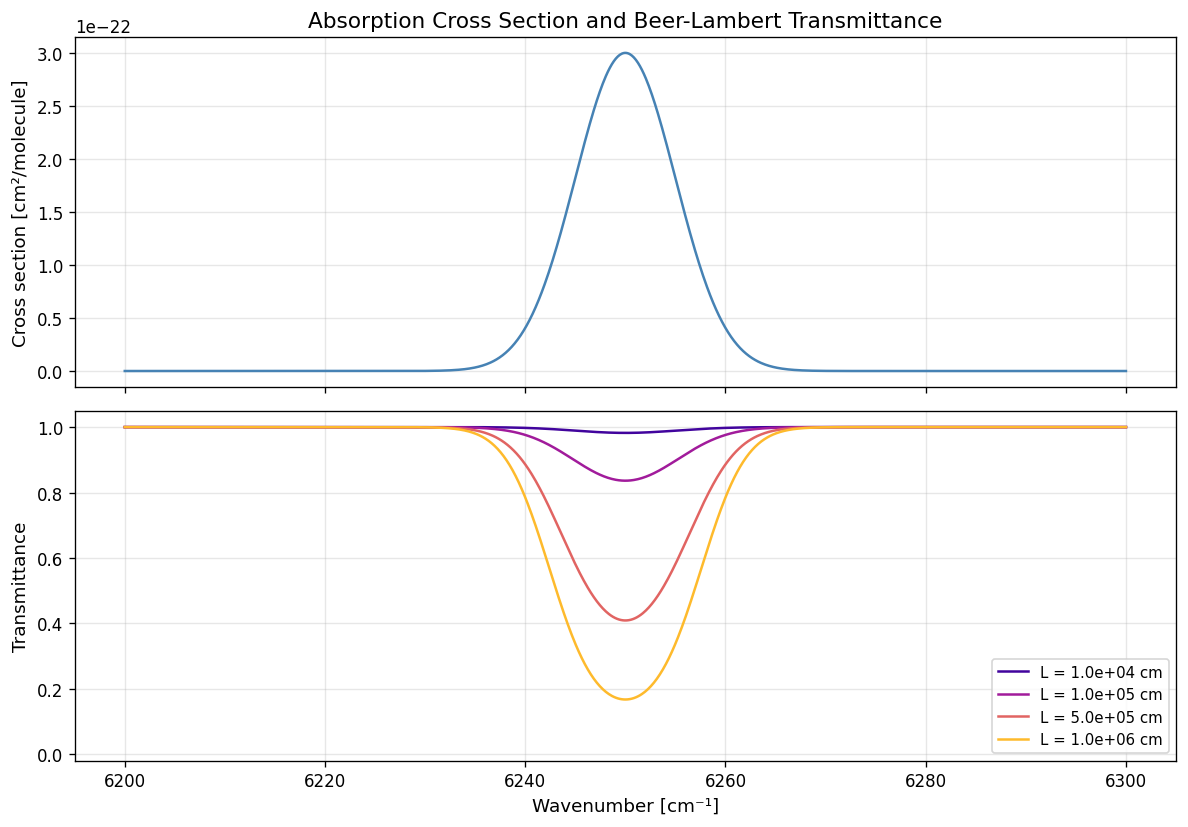

In [6]:
nu = np.linspace(6200, 6300, 1000)

# Gaussian absorption cross section centred at 6250 cm⁻¹
nu0    = 6250.0
width  = 5.0       # cm⁻¹
xsec   = sigma_peak * np.exp(-0.5 * ((nu - nu0) / width)**2)

# Compare several path lengths
path_lengths = [1e4, 1e5, 5e5, 1e6]  # cm
demo_beer_lambert(nu, xsec, n_co2, path_lengths,
                  savefig='../figures/01b_beer_lambert_spectral.png')

## 4. Multi-Layer Atmosphere

A realistic atmosphere can be decomposed into layers with different $P$, $T$, and thus different $n_i$:

Layer number densities [molecules/cm³]:
  Layer 1: P=1013 hPa  T=288 K  n=1.070e+16
  Layer 2: P=700 hPa  T=275 K  n=7.743e+15
  Layer 3: P=500 hPa  T=255 K  n=5.965e+15
  Layer 4: P=300 hPa  T=230 K  n=3.968e+15
  Layer 5: P=100 hPa  T=200 K  n=1.521e+15


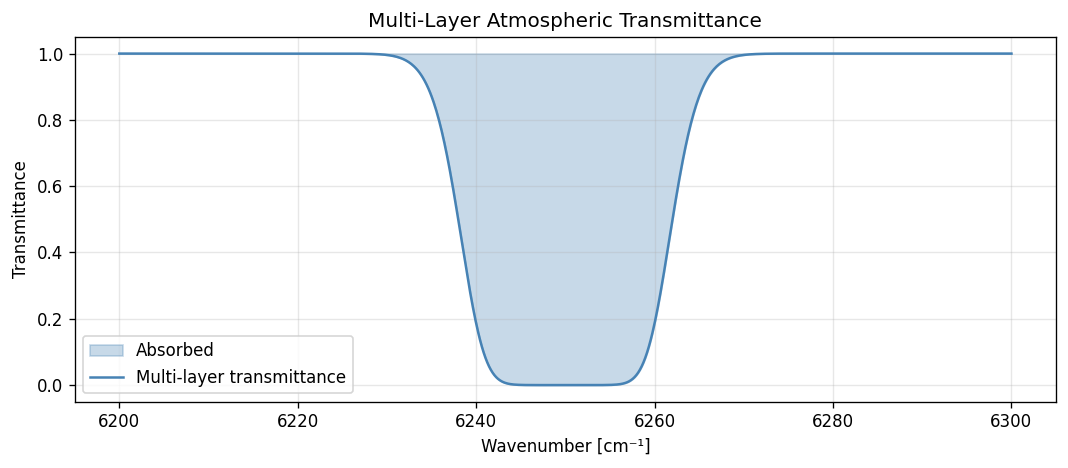

In [7]:
# 5 layers: surface → tropopause
pressures_Pa = np.array([101325, 70000, 50000, 30000, 10000])
temps_K      = np.array([288,    275,   255,   230,   200  ])
vmr_co2      = np.full(5, 420e-6)
layer_dz_cm  = np.full(5, 4e6)  # ~4 km each = 4e5 m = 4e7 cm... keep modest
layer_dz_cm  = np.array([1e6, 1e6, 1.5e6, 2e6, 4e6])  # variable layer depth

n_layers = np.array([number_density_from_pT(P, T, vmr) 
                     for P, T, vmr in zip(pressures_Pa, temps_K, vmr_co2)])

print('Layer number densities [molecules/cm³]:')
for i, (P, T, n) in enumerate(zip(pressures_Pa, temps_K, n_layers)):
    print(f'  Layer {i+1}: P={P/100:.0f} hPa  T={T} K  n={n:.3e}')

tau_total = multilayer_optical_depth(xsec, n_layers, layer_dz_cm)
T_total   = transmittance(tau_total)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(nu, T_total, 1, alpha=0.3, color='steelblue', label='Absorbed')
ax.plot(nu, T_total, color='steelblue', lw=1.5, label='Multi-layer transmittance')
ax.set_xlabel('Wavenumber [cm⁻¹]'); ax.set_ylabel('Transmittance')
ax.set_title('Multi-Layer Atmospheric Transmittance')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/01c_multilayer_transmittance.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Takeaways

- The Beer-Lambert law describes **exponential attenuation** of radiation through an absorbing gas.
- Optical depth τ = 1 marks the transition from optically thin to optically thick.
- In a real atmosphere, each layer contributes additively to the total optical depth.
- CO₂ absorption features at 6250 cm⁻¹ (1.6 µm) are clearly resolvable in satellite spectra.